# Quickstart: NOAA GEFS forecast, 10 day, 0.25 degree and analysis, 0.25 degree, virtual - dynamical.org Icechunk Zarr

NOAA's Global Ensemble Forecast System (GEFS) is a 31-member global ensemble on a 0.25° grid. These two virtual datasets carry the complete 0.25° GEFS output from October 2020 to present by referencing NOAA's GRIB files rather than copying them: 34 surface and single-level variables in each at the start, growing to 38 as NOAA added fields through October 2022. The forecast holds all four daily runs (00, 06, 12 and 18 UTC), every member, 3 hourly to 240 hours; the analysis is the same fields every 3 hours. Each time step is one global field, so they suit map-oriented access. For long time series at a point, or for the 00 UTC runs out to 35 days, use the time-optimized [NOAA GEFS forecast, 35 day](https://dynamical.org/catalog/noaa-gefs-forecast-35-day/) and [NOAA GEFS analysis](https://dynamical.org/catalog/noaa-gefs-analysis/), which carry the most used variables.

Dataset documentation:
- Forecast, 10 day, 0.25 degree: https://dynamical.org/catalog/noaa-gefs-forecast-10-day-0-25-degree-virtual/
- Analysis, 0.25 degree: https://dynamical.org/catalog/noaa-gefs-analysis-0-25-degree-virtual/

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
# TEMPORARY: these datasets are not in the dynamical.org catalog yet, so this cell opens their
# Icechunk stores directly. Once they are published, replace this whole cell with:
#
#     import dynamical_catalog
#
#     forecast = dynamical_catalog.open("noaa-gefs-forecast-10-day-0-25-degree-virtual", chunks=None)
#     analysis = dynamical_catalog.open("noaa-gefs-analysis-0-25-degree-virtual", chunks=None)
#     forecast
import icechunk
import xarray as xr


def open_virtual(dataset_id, **kwargs):
    # Chunks reference NOAA's public GEFS archive, which icechunk must be allowed to read anonymously.
    authorize = icechunk.containers_credentials(
        {"s3://noaa-gefs-pds/": icechunk.s3_anonymous_credentials()}
    )
    storage = icechunk.s3_storage(
        bucket="dynamical-noaa-gefs", prefix=f"{dataset_id}/v0.1.0.icechunk", region="us-west-2", anonymous=True
    )
    repo = icechunk.Repository.open(storage, authorize_virtual_chunk_access=authorize)
    return xr.open_zarr(repo.readonly_session("main").store, consolidated=False, **kwargs)


forecast = open_virtual("noaa-gefs-forecast-10-day-0-25-degree-virtual", chunks=None)
analysis = open_virtual("noaa-gefs-analysis-0-25-degree-virtual", chunks=None)
forecast

<xarray.Dataset> Size: 7PB
Dimensions:                                            (init_time: 8715,
                                                        ensemble_member: 31,
                                                        lead_time: 81,
                                                        latitude: 721,
                                                        longitude: 1440)
Coordinates:
  * init_time                                          (init_time) datetime64[ns] 70kB ...
    expected_forecast_length                           (init_time) timedelta64[us] 70kB ...
  * ensemble_member                                    (ensemble_member) int16 62B ...
  * lead_time                                          (lead_time) timedelta64[us] 648B ...
    valid_time                                         (init_time, lead_time) datetime64[ns] 6MB ...
  * latitude                                           (latitude) float64 6kB ...
  * longitude                                          (longitude) float64 12kB ...
    spatial_ref                                        int64 8B ...
Data variables: (12/38)
    categorical_freezing_rain_surface                  (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    categorical_snow_surface                           (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    categorical_rain_surface                           (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_available_potential_energy_180_0mb      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_available_potential_energy_surface      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_inhibition_180_0mb                      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    ...                                                 ...
    upward_short_wave_radiation_flux_surface           (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_gust_surface                                  (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_u_10m                                         (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    visibility_surface                                 (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_v_10m                                         (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    volumetric_soil_moisture_0_10cm                    (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
Attributes:
    dataset_id:           noaa-gefs-forecast-10-day-0-25-degree-virtual
    dataset_version:      0.1.0
    name:                 NOAA GEFS forecast, 10 day, 0.25 degree, virtual
    description:          Weather forecasts from the Global Ensemble Forecast...
    attribution:          NOAA NWS NCEP GEFS data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2020-10-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-240 hours ahead
    forecast_resolution:  Forecast step 3 hourly

The forecast has two time dimensions, `init_time` every 6 hours and `lead_time` every 3 hours to 240 hours, plus an `ensemble_member` dimension whose member 0 is the control. `valid_time` combines the two time dimensions. The analysis is one 3 hourly `time` dimension on the same grid with the same 38 variables.

Accumulations, averages, maxima and minima cover the 3 or 6 hours ending at each step, alternating, as each variable's `comment` attribute says, and have no value at lead time 0. Both datasets hold surface and single-level fields only; GEFS's pressure-level output is published at 0.5° and is not part of these two datasets.

In [3]:
analysis

<xarray.Dataset> Size: 6TB
Dimensions:                                            (time: 17430,
                                                        latitude: 721,
                                                        longitude: 1440)
Coordinates:
  * time                                               (time) datetime64[ns] 139kB ...
  * latitude                                           (latitude) float64 6kB ...
  * longitude                                          (longitude) float64 12kB ...
    spatial_ref                                        int64 8B ...
Data variables: (12/38)
    categorical_freezing_rain_surface                  (time, latitude, longitude) float64 145GB ...
    categorical_ice_pellets_surface                    (time, latitude, longitude) float64 145GB ...
    convective_available_potential_energy_180_0mb      (time, latitude, longitude) float64 145GB ...
    convective_inhibition_180_0mb                      (time, latitude, longitude) float64 145GB ...
    dew_point_temperature_2m                           (time, latitude, longitude) float64 145GB ...
    categorical_rain_surface                           (time, latitude, longitude) float64 145GB ...
    ...                                                 ...
    volumetric_soil_moisture_0_10cm                    (time, latitude, longitude) float64 145GB ...
    wind_u_10m                                         (time, latitude, longitude) float64 145GB ...
    upward_long_wave_radiation_flux_top_of_atmosphere  (time, latitude, longitude) float64 145GB ...
    wind_gust_surface                                  (time, latitude, longitude) float64 145GB ...
    upward_short_wave_radiation_flux_surface           (time, latitude, longitude) float64 145GB ...
    wind_v_10m                                         (time, latitude, longitude) float64 145GB ...
Attributes:
    dataset_id:          noaa-gefs-analysis-0-25-degree-virtual
    dataset_version:     0.1.0
    name:                NOAA GEFS analysis, 0.25 degree, virtual
    description:         Weather analysis from the Global Ensemble Forecast S...
    attribution:         NOAA NWS NCEP GEFS data processed by dynamical.org f...
    license:             CC-BY-4.0
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2020-10-01 00:00:00 UTC to Present
    time_resolution:     3 hours

### A map

Storm Filomena buried central Spain on 8–9 January 2021, Madrid's heaviest snowfall in decades. Snow depth is one of the fields the time-optimized GEFS datasets do not carry.

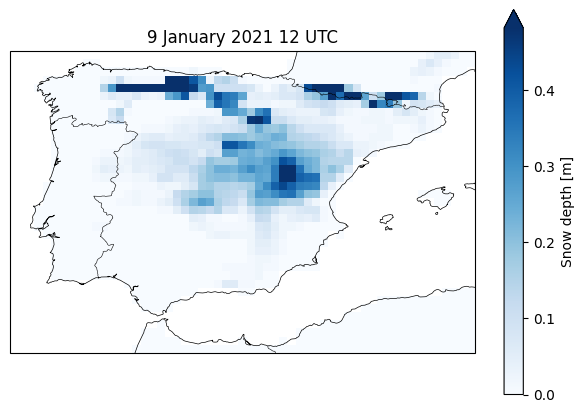

In [4]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

snow = (
    analysis["snow_thickness_surface"]
    .sel(time="2021-01-09T12", latitude=slice(44, 35), longitude=slice(-10, 4))
    .load()
)
plot = snow.plot(
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(), cmap="Blues", center=False, robust=True, size=5, aspect=1.5,
)
ax = plot.axes
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_title("9 January 2021 12 UTC");

### A time series

The February 2021 cold wave left millions of Texans without power; Dallas–Fort Worth airport observed −19 °C on 16 February. The top 10 cm of model soil cools and thaws more slowly than the air above it.

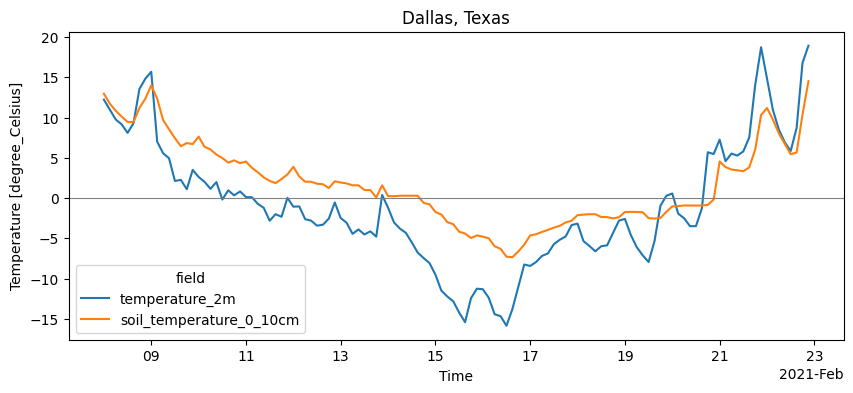

In [5]:
dallas = (
    analysis[["temperature_2m", "soil_temperature_0_10cm"]]
    .sel(latitude=32.78, longitude=-96.80, method="nearest")
    .sel(time=slice("2021-02-08", "2021-02-22"))
    .load()
)
dallas = dallas.to_dataarray("field").assign_attrs(long_name="Temperature", units="degree_Celsius")
dallas.plot(x="time", hue="field", size=4, aspect=2.5)
plt.axhline(0, color="0.5", linewidth=0.8)
plt.title("Dallas, Texas");

## How hot did the ensemble expect the July 2022 heat to get?

The United Kingdom passed 40 °C for the first time on 19 July 2022, at RAF Coningsby in Lincolnshire. Every member of the run issued at 18 UTC on 13 July is plotted against the analysis; the 18 UTC runs exist only in this dataset. Both fields are the maximum over the 3 or 6 hours ending at each step.

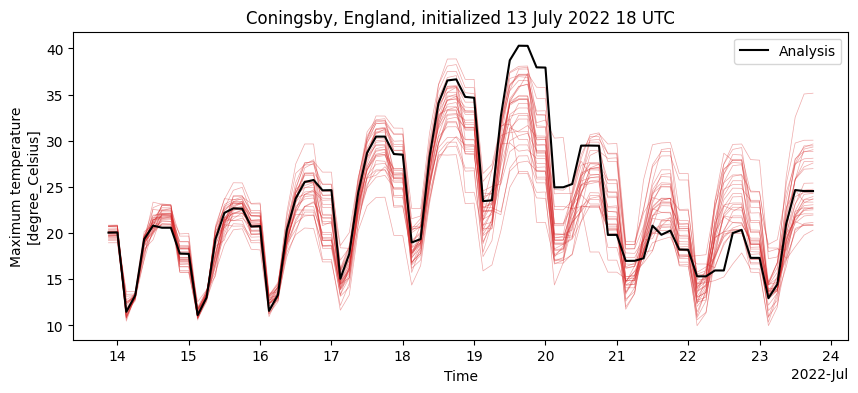

In [6]:
coningsby = dict(latitude=53.09, longitude=-0.17, method="nearest")

plume = (
    forecast["maximum_temperature_2m"]
    .sel(init_time="2022-07-13T18", lead_time=slice("3h", "240h"))
    .sel(**coningsby)
    .load()
)
plume.plot(
    x="valid_time", hue="ensemble_member", color="tab:red",
    linewidth=0.5, alpha=0.4, add_legend=False, size=4, aspect=2.5,
)
ax = plt.gca()
(
    analysis["maximum_temperature_2m"]
    .sel(time=slice("2022-07-13T21", "2022-07-23T18"))
    .sel(**coningsby)
    .plot(ax=ax, color="black", label="Analysis")
)
ax.legend()
ax.set_title("Coningsby, England, initialized 13 July 2022 18 UTC");

## Where did the ensemble put Hurricane Ian's winds?

Ian made landfall on Cayo Costa, Florida at 19 UTC on 28 September 2022 as a category 4 hurricane, after days of forecasts that shifted along the state's Gulf coast. For two 18 UTC runs, four days and two days before landfall, each map shows the fraction of members whose peak gust on the 28th exceeds 25 m/s.

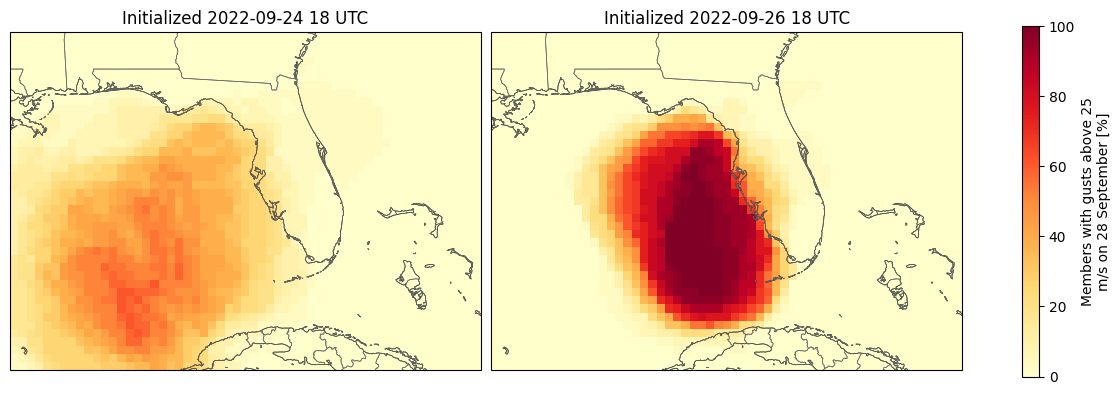

In [7]:
import pandas as pd
import xarray as xr

florida = dict(latitude=slice(32, 22), longitude=slice(-90, -76))
day = pd.Timestamp("2022-09-28")
probability = []
for init_time in pd.to_datetime(["2022-09-24T18", "2022-09-26T18"]):
    gusts = (
        forecast["wind_gust_surface"]
        .sel(init_time=init_time, lead_time=slice(day - init_time, day + pd.Timedelta("1D") - init_time), **florida)
        .load()
    )
    probability.append((gusts.max("lead_time") > 25).mean("ensemble_member") * 100)
probability = xr.concat(probability, dim="init_time")
probability.attrs = {"long_name": "Members with gusts above 25 m/s on 28 September", "units": "%"}

plot = probability.plot(
    col="init_time", subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(), cmap="YlOrRd", vmin=0, vmax=100, size=4, aspect=1.4,
)
for ax, init_time in zip(plot.axs.flat, probability["init_time"].values):
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)
    ax.set_title(f"Initialized {str(init_time)[:13].replace('T', ' ')} UTC")

## Animated: two afternoons of severe weather on the Plains

Tornadoes struck the Omaha suburbs on the afternoon of 26 April 2024 and central Oklahoma the following night. Surface-based CAPE, one of the fields the time-optimized GEFS datasets do not carry, builds along the dryline each afternoon and collapses overnight in the 3 hourly analysis.

In [8]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

cape = (
    analysis["convective_available_potential_energy_surface"]
    .sel(time=slice("2024-04-26T12", "2024-04-28T06"), latitude=slice(46, 30), longitude=slice(-104, -86))
    .load()
)

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=72, subplot_kw={"projection": ccrs.PlateCarree()})
mesh = cape.isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap="YlOrRd", vmin=0, vmax=4000)
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.STATES, edgecolor="0.4", linewidth=0.5)


def draw_frame(i):
    mesh.set_array(cape.isel(time=i).values.ravel())
    ax.set_title(str(cape.time.values[i])[:16])


anim = FuncAnimation(fig, draw_frame, frames=cape.sizes["time"], interval=300)
plt.close(fig)
HTML(anim.to_jshtml())

## Community challenge

- With four runs a day, how much does a 5-day ensemble forecast change from one run to the next, and is the 06 or 18 UTC run ever the one that first sees an event?
- Hurricane Otis intensified from tropical storm to category 5 in a day before striking Acapulco on 25 October 2023. Did any member's `wind_gust_surface` or `pressure_reduced_to_mean_sea_level` come close, at any lead time?
- Surface CAPE, convective inhibition and 0–3 km storm relative helicity are all here. How well does the ensemble's overlap of high CAPE and high helicity a day ahead match where tornado outbreaks occurred?
- The 0–10 cm soil moisture and the surface heat fluxes are analysed every 3 hours. How quickly do model soils dry during a flash drought, and does the latent heat flux fall before the 2 m temperature rises?